In [1]:
# ==========================================================
# Step-1 : Import Required Libraries
# ==========================================================

# -------------------------------
# System
# -------------------------------
import os
import warnings

os.environ["SCIPY_ARRAY_API"] = "1"
warnings.filterwarnings("ignore")

# -------------------------------
# Numerical Computing
# -------------------------------
from pathlib import Path
import numpy as np
import pandas as pd

# -------------------------------
# Spatial Data
# -------------------------------
import geopandas as gpd
import pyreadstat

from libpysal.weights import KNN

# -------------------------------
# Visualization
# -------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Machine Learning
# -------------------------------
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler
)

from sklearn.feature_selection import chi2

from sklearn.model_selection import (

    GroupShuffleSplit,

    StratifiedKFold,

    GridSearchCV

)


# -------------------------------
# Imbalanced Learning
# -------------------------------
from imblearn.combine import SMOTETomek

# -------------------------------
# Classification Models
# -------------------------------
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (

    RandomForestClassifier,

    ExtraTreesClassifier,

    GradientBoostingClassifier,

    AdaBoostClassifier

)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

# -------------------------------
# Model Evaluation
# -------------------------------
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    cohen_kappa_score,

    matthews_corrcoef,

    roc_auc_score,

    average_precision_score,

    balanced_accuracy_score,

    confusion_matrix,

    roc_curve,

    precision_recall_curve,

    log_loss

)

# -------------------------------
# XAI
# -------------------------------
import shap

print("="*70)
print("Spatial Machine Learning Libraries Loaded Successfully")
print("="*70)

Spatial Machine Learning Libraries Loaded Successfully


In [2]:
# ==========================================================
# Step-2 : Load Data
# ==========================================================

# ----------------------------------------------------------
# File Paths
# ----------------------------------------------------------

BDHS_FILE = Path(r"F:/Thesis/GPS DATA/Stunting_new.SAV")

GPS_FILE = Path(r"F:/Thesis/GPS DATA/Division/BDGE81FL.shp")

ENV_FILE = Path(r"F:/Thesis/GPS DATA/bdhs_env_2022.csv")

# ----------------------------------------------------------
# Check File Availability
# ----------------------------------------------------------

for file in [BDHS_FILE, GPS_FILE, ENV_FILE]:

    if not file.exists():

        raise FileNotFoundError(

            f"File not found:\n{file}"

        )

# ----------------------------------------------------------
# Load BDHS Dataset
# ----------------------------------------------------------

df, meta = pyreadstat.read_sav(

    BDHS_FILE

)

# ----------------------------------------------------------
# Load GPS Shapefile
# ----------------------------------------------------------

gps = gpd.read_file(

    GPS_FILE

)

# ----------------------------------------------------------
# Load Environmental Dataset
# ----------------------------------------------------------

env = pd.read_csv(

    ENV_FILE

)

# ----------------------------------------------------------
# Dataset Summary
# ----------------------------------------------------------

print("="*70)

print("DATA SUCCESSFULLY LOADED")

print("="*70)

print(f"\nBDHS Dataset Shape : {df.shape}")

print(f"GPS Dataset Shape  : {gps.shape}")

print(f"ENV Dataset Shape  : {env.shape}")

# ----------------------------------------------------------
# Basic Information
# ----------------------------------------------------------

print("\n")

print("="*70)

print("DATASET INFORMATION")

print("="*70)

print(f"\nBDHS Variables : {df.shape[1]}")

print(f"GPS Variables  : {gps.shape[1]}")

print(f"ENV Variables  : {env.shape[1]}")

print("\n")

print("="*70)

print("FIRST FIVE ROWS")

print("="*70)

print("\nBDHS")

display(df.head())

print("\nGPS")

display(gps.head())

print("\nENVIRONMENT")

display(env.head())

DATA SUCCESSFULLY LOADED

BDHS Dataset Shape : (4153, 25)
GPS Dataset Shape  : (674, 21)
ENV Dataset Shape  : (674, 15)


DATASET INFORMATION

BDHS Variables : 25
GPS Variables  : 21
ENV Variables  : 15


FIRST FIVE ROWS

BDHS


,dhsclust,Age_,Division,Residence,Mother_education,Water_source,Toilet_facility,Religion,Members,Relationship_to_household_head,...,Father_education,Mother_Working,Who_make_decision_about_health,Twin_child,Child_sex,Diarrhea,Fever,Cough,Short_rapid_breaths,Stunting_
0,1.0,2.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,...,2.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,1.0,2.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,...,2.0,0.0,4.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,4.0,5.0,1.0,3.0,1.0,1.0,1.0,2.0,1.0,...,3.0,0.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,3.0,5.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,...,2.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2.0,3.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,2.0,0.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0



GPS


,DHSID,DHSCC,DHSYEAR,DHSCLUST,CCFIPS,ADM1FIPS,ADM1FIPSNA,ADM1SALBNA,ADM1SALBCO,ADM1DHS,...,DHSREGCO,DHSREGNA,SOURCE,URBAN_RURA,LATNUM,LONGNUM,ALT_GPS,ALT_DEM,DATUM,geometry
0,BD202200000001,BD,2022.0,1.0,BG,NULL,NULL,NULL,NULL,1.0,...,1.0,Barishal,GPS,U,22.717315,90.373835,9999.0,9.0,WGS84,POINT (90.37384 22.71731)
1,BD202200000002,BD,2022.0,2.0,BG,NULL,NULL,NULL,NULL,1.0,...,1.0,Barishal,GPS,U,22.717246,90.382553,9999.0,7.0,WGS84,POINT (90.38255 22.71725)
2,BD202200000003,BD,2022.0,3.0,BG,NULL,NULL,NULL,NULL,1.0,...,1.0,Barishal,GPS,U,22.713827,90.383011,9999.0,8.0,WGS84,POINT (90.38301 22.71383)
3,BD202200000004,BD,2022.0,4.0,BG,NULL,NULL,NULL,NULL,1.0,...,1.0,Barishal,GPS,U,22.698693,90.368405,9999.0,12.0,WGS84,POINT (90.36841 22.69869)
4,BD202200000005,BD,2022.0,5.0,BG,NULL,NULL,NULL,NULL,1.0,...,1.0,Barishal,GPS,U,22.692715,90.366816,9999.0,9.0,WGS84,POINT (90.36682 22.69272)



ENVIRONMENT


,DHSCLUST,URBAN_RURA,rainfall_mm_yr,temperature_celsius,relative_humidity_pct,soil_moisture,ndvi,lst_celsius,elevation_m,slope_degrees,flood_occurrence_pct,pop_density,pdsi_drought_index,climatic_water_deficit_mm,pet_mm
0,1,U,2209.248199,25.609667,77.414685,0.284659,0.556455,27.411023,7.555220,0.086140,76.360541,38.699318,0.289553,21.428627,113.260877
1,2,U,2229.652801,25.613442,77.439372,0.283825,0.543719,27.372885,7.361611,0.088722,74.902813,37.065918,0.285567,21.438001,113.244031
2,3,U,2231.133664,25.614284,77.430151,0.283955,0.544809,27.414004,7.378851,0.087804,74.698266,37.676147,0.287546,21.441367,113.248565
3,4,U,2201.950407,25.608282,77.381189,0.285486,0.572948,27.641720,7.531870,0.083279,78.607022,41.911776,0.308225,21.441208,113.317357
4,5,U,2200.610217,25.607534,77.376230,0.285652,0.573268,27.701318,7.507608,0.082217,80.186827,42.017608,0.315058,21.448659,113.334136


In [3]:
# ==========================================================
# Step-3 : GPS Cleaning
# ==========================================================

print("="*70)
print("GPS DATA CLEANING")
print("="*70)

# Keep required variables
gps = gps[
    [
        "DHSCLUST",
        "LATNUM",
        "LONGNUM"
    ]
].copy()

# Rename
gps.rename(
    columns={
        "DHSCLUST":"dhsclust",
        "LATNUM":"lat",
        "LONGNUM":"lon"
    },
    inplace=True
)

# Integer Cluster ID
gps["dhsclust"] = gps["dhsclust"].astype(int)

print("Rows :",len(gps))
print("Unique Clusters :",gps["dhsclust"].nunique())

# Missing values
print("\nMissing Values")

print(gps.isna().sum())

# Remove missing coordinates
gps = gps.dropna(
    subset=["lat","lon"]
)

# Remove zero coordinates
gps = gps[
    (gps["lat"]!=0)
    &
    (gps["lon"]!=0)
]

# Remove duplicate clusters
gps = gps.drop_duplicates(
    subset="dhsclust"
)

gps = gps.reset_index(
    drop=True
)

print("\nFinal GPS Shape :",gps.shape)

display(gps.head())

GPS DATA CLEANING
Rows : 674
Unique Clusters : 674

Missing Values
dhsclust    0
lat         0
lon         0
dtype: int64

Final GPS Shape : (674, 3)


,dhsclust,lat,lon
0,1,22.717315,90.373835
1,2,22.717246,90.382553
2,3,22.713827,90.383011
3,4,22.698693,90.368405
4,5,22.692715,90.366816


In [4]:
# ==========================================================
# Step-4 : Environmental Data Cleaning and Quality Assessment
# ==========================================================

# ----------------------------------------------------------
# Standardize Column Names
# ----------------------------------------------------------

env.columns = (

    env.columns

       .str.strip()

       .str.lower()

)

# ----------------------------------------------------------
# Check Required Column
# ----------------------------------------------------------

if "dhsclust" not in env.columns:

    raise ValueError(

        "'dhsclust' column is missing from environmental dataset."

    )

# ----------------------------------------------------------
# Convert Cluster ID
# ----------------------------------------------------------

env["dhsclust"] = env["dhsclust"].astype(int)

# ----------------------------------------------------------
# Dataset Summary
# ----------------------------------------------------------

print("=" * 70)
print("ENVIRONMENTAL DATA SUMMARY")
print("=" * 70)

print("Total Records :", len(env))
print("Total Variables :", env.shape[1])
print("Unique Clusters :", env["dhsclust"].nunique())

# ----------------------------------------------------------
# Missing Value Assessment
# ----------------------------------------------------------

missing_summary = (

    env

    .isnull()

    .sum()

    .sort_values(

        ascending=False

    )

)

missing_summary = missing_summary[
    missing_summary > 0
]

print("\n")

print("=" * 70)
print("MISSING VALUES")
print("=" * 70)

if len(missing_summary) == 0:

    print("No missing values detected.")

else:

    display(

        missing_summary.to_frame(

            name="Missing_Count"

        )

    )

# ----------------------------------------------------------
# Duplicate Cluster Check
# ----------------------------------------------------------

duplicate_clusters = env[

    env.duplicated(

        subset="dhsclust",

        keep=False

    )

]

print("\nDuplicate Cluster Records :", len(duplicate_clusters))

# ----------------------------------------------------------
# Aggregate Duplicate Clusters
# ----------------------------------------------------------

numeric_columns = env.select_dtypes(

    include=np.number

).columns.tolist()

numeric_columns.remove("dhsclust")

env_cluster = (

    env

    .groupby(

        "dhsclust",

        as_index=False

    )[numeric_columns]

    .mean()

)

# ----------------------------------------------------------
# Final Integrity Check
# ----------------------------------------------------------

print("\n")

print("=" * 70)
print("AFTER AGGREGATION")
print("=" * 70)

print("Rows :", len(env_cluster))
print("Unique Clusters :", env_cluster["dhsclust"].nunique())

# ----------------------------------------------------------
# Environmental Variable Summary
# ----------------------------------------------------------

print("\n")

print("=" * 70)
print("ENVIRONMENTAL VARIABLES")
print("=" * 70)

display(

    env_cluster.describe().T

)

ENVIRONMENTAL DATA SUMMARY
Total Records : 674
Total Variables : 15
Unique Clusters : 674


MISSING VALUES


,Missing_Count
temperature_celsius,1
relative_humidity_pct,1
soil_moisture,1



Duplicate Cluster Records : 0


AFTER AGGREGATION
Rows : 674
Unique Clusters : 674


ENVIRONMENTAL VARIABLES


,count,mean,std,min,25%,50%,75%,max
dhsclust,674.0,338.281899,195.007130,1.000000,170.250000,338.500000,506.750000,675.000000
rainfall_mm_yr,674.0,2442.368128,720.278624,1524.994444,1910.826775,2285.885667,2802.647905,5259.368516
temperature_celsius,673.0,25.035507,0.559504,23.126007,24.674741,25.172732,25.443346,26.070054
relative_humidity_pct,673.0,76.657445,1.455188,72.935482,75.725966,76.585078,77.558998,81.010406
soil_moisture,673.0,0.304889,0.033163,0.165389,0.289731,0.297886,0.313465,0.405108
ndvi,674.0,0.564288,0.093680,0.243495,0.530325,0.594290,0.623644,0.795394
lst_celsius,674.0,27.543428,0.991875,25.223451,26.861051,27.365814,27.997852,30.808907
elevation_m,674.0,16.992976,15.234229,1.495062,8.351489,13.060197,19.443307,222.665026
slope_degrees,674.0,0.112519,0.235599,0.026846,0.054036,0.066451,0.096606,4.325426
flood_occurrence_pct,674.0,34.571716,23.605938,1.909091,16.223760,27.411555,47.261395,96.299246


In [5]:
# ==========================================================
# Step-5 : Merge BDHS, GPS and Environmental Data
# ==========================================================

# ----------------------------------------------------------
# Rename Variables
# ----------------------------------------------------------

df = df.rename(
    columns={
        "Stunting_": "stunting",
        "v001": "dhsclust",
        "v024": "division",
        "v025": "residence"
    }
)

df["dhsclust"] = df["dhsclust"].astype(int)

# ----------------------------------------------------------
# Original Dataset Summary
# ----------------------------------------------------------

print("="*70)
print("BDHS DATA SUMMARY")
print("="*70)

print("Observations :", len(df))
print("Variables    :", df.shape[1])
print("Unique Clusters :", df["dhsclust"].nunique())

# ----------------------------------------------------------
# Merge GPS Coordinates
# ----------------------------------------------------------

df = df.merge(

    gps,

    on="dhsclust",

    how="left",

    validate="many_to_one"

)

# ----------------------------------------------------------
# Merge Environmental Variables
# ----------------------------------------------------------

df = df.merge(

    env_cluster,

    on="dhsclust",

    how="left",

    validate="many_to_one"

)

# ----------------------------------------------------------
# Merge Quality Assessment
# ----------------------------------------------------------

print("\n")

print("="*70)
print("MERGE QUALITY CHECK")
print("="*70)

print("Missing Latitude :", df["lat"].isna().sum())
print("Missing Longitude:", df["lon"].isna().sum())

env_missing = (

    df[env_cluster.columns.drop("dhsclust")]

    .isna()

    .sum()

    .sum()

)

print("Missing Environmental Values :", env_missing)

# ----------------------------------------------------------
# Remove Missing Coordinates
# ----------------------------------------------------------

df = df.dropna(

    subset=[

        "lat",

        "lon",

        "stunting"

    ]

).reset_index(drop=True)

# ----------------------------------------------------------
# Remove Invalid Coordinates
# ----------------------------------------------------------

df = df[

    (df["lat"] != 0)

    &

    (df["lon"] != 0)

].reset_index(drop=True)

# ----------------------------------------------------------
# Final Dataset Summary
# ----------------------------------------------------------

print("\n")

print("="*70)
print("FINAL ANALYTICAL DATASET")
print("="*70)

print("Observations :", len(df))
print("Variables    :", df.shape[1])

print("Unique Clusters :", df["dhsclust"].nunique())

print(

    "Stunting Prevalence :",

    round(

        df["stunting"].mean()*100,

        2

    ),

    "%"

)

# ----------------------------------------------------------
# Duplicate Observation Check
# ----------------------------------------------------------

print("\nDuplicate Rows :", df.duplicated().sum())

# ----------------------------------------------------------
# Dataset Preview
# ----------------------------------------------------------

display(df.head())

BDHS DATA SUMMARY
Observations : 4153
Variables    : 25
Unique Clusters : 671


MERGE QUALITY CHECK
Missing Latitude : 0
Missing Longitude: 0
Missing Environmental Values : 45


FINAL ANALYTICAL DATASET
Observations : 4153
Variables    : 40
Unique Clusters : 671
Stunting Prevalence : 22.61 %

Duplicate Rows : 75


,dhsclust,Age_,Division,Residence,Mother_education,Water_source,Toilet_facility,Religion,Members,Relationship_to_household_head,...,soil_moisture,ndvi,lst_celsius,elevation_m,slope_degrees,flood_occurrence_pct,pop_density,pdsi_drought_index,climatic_water_deficit_mm,pet_mm
0,1,2.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,...,0.284659,0.556455,27.411023,7.555220,0.086140,76.360541,38.699318,0.289553,21.428627,113.260877
1,1,2.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,...,0.284659,0.556455,27.411023,7.555220,0.086140,76.360541,38.699318,0.289553,21.428627,113.260877
2,1,4.0,5.0,1.0,3.0,1.0,1.0,1.0,2.0,1.0,...,0.284659,0.556455,27.411023,7.555220,0.086140,76.360541,38.699318,0.289553,21.428627,113.260877
3,1,3.0,5.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,...,0.284659,0.556455,27.411023,7.555220,0.086140,76.360541,38.699318,0.289553,21.428627,113.260877
4,2,3.0,5.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,...,0.283825,0.543719,27.372885,7.361611,0.088722,74.902813,37.065918,0.285567,21.438001,113.244031


In [6]:
# ==========================================================
# Step-6 : Define Analytical Variables
# ==========================================================

print("=" * 70)
print("DEFINE ANALYTICAL VARIABLES")
print("=" * 70)

# ----------------------------------------------------------
# Outcome Variable
# ----------------------------------------------------------

target = "stunting"

print(f"\nOutcome Variable : {target}")

print("\nOutcome Distribution")

print(

    df[target]

    .value_counts()

    .sort_index()

)

print("\nOutcome Percentage (%)")

print(

    round(

        df[target]

        .value_counts(normalize=True)

        * 100,

        2

    )

)

# ----------------------------------------------------------
# Environmental Variables
# ----------------------------------------------------------

env_vars = [

    "rainfall_mm_yr",

    "temperature_celsius",

    "relative_humidity_pct",

    "soil_moisture",

    "ndvi",

    "lst_celsius",

    "elevation_m",

    "slope_degrees",

    "flood_occurrence_pct",

    "pop_density",

    "pdsi_drought_index",

    "climatic_water_deficit_mm",

    "pet_mm"

]

# ----------------------------------------------------------
# Socioeconomic Variables
# ----------------------------------------------------------

socio_vars = [

    "Age_",

    "Division",

    "Residence",

    "Mother_education",

    "Water_source",

    "Toilet_facility",

    "Religion",

    "Members",

    "Relationship_to_household_head",

    "Wealth",

    "Age_at_1st_birth",

    "Maternal_Height",

    "BMI",

    "Contraception",

    "Father_education",

    "Mother_Working",

    "Who_make_decision_about_health",

    "Twin_child",

    "Child_sex",

    "Diarrhea",

    "Fever",

    "Cough",

    "Short_rapid_breaths"

]

# ----------------------------------------------------------
# Spatial Variables
# ----------------------------------------------------------

spatial_vars = [

    "lat",

    "lon"

]

# ----------------------------------------------------------
# Keep Existing Variables Only
# ----------------------------------------------------------

env_vars = [

    v for v in env_vars

    if v in df.columns

]

socio_vars = [

    v for v in socio_vars

    if v in df.columns

]

spatial_vars = [

    v for v in spatial_vars

    if v in df.columns

]

# ----------------------------------------------------------
# Final Predictor Variables
# ----------------------------------------------------------

all_vars = (

    env_vars +

    socio_vars +

    spatial_vars

)

# ----------------------------------------------------------
# Variable Summary
# ----------------------------------------------------------

print("\n")
print("=" * 70)
print("VARIABLE SUMMARY")
print("=" * 70)

print(f"Environmental Variables : {len(env_vars)}")

print(env_vars)

print("\n")

print(f"Socioeconomic Variables : {len(socio_vars)}")

print(socio_vars)

print("\n")

print(f"Spatial Variables : {len(spatial_vars)}")

print(spatial_vars)

print("\n")

print(f"Total Predictor Variables : {len(all_vars)}")

# ----------------------------------------------------------
# Missing Value Summary
# ----------------------------------------------------------

missing_summary = (

    df[all_vars + [target]]

    .isnull()

    .sum()

    .sort_values(

        ascending=False

    )

)

missing_summary = missing_summary[

    missing_summary > 0

]

print("\n")
print("=" * 70)
print("MISSING VALUE SUMMARY")
print("=" * 70)

if len(missing_summary) == 0:

    print("No missing values detected.")

else:

    print(missing_summary)

# ----------------------------------------------------------
# Complete-Case Analysis
# ----------------------------------------------------------

before = len(df)

df = df.dropna(

    subset=all_vars + [target]

).reset_index(

    drop=True

)

after = len(df)

print("\n")
print("=" * 70)
print("COMPLETE-CASE ANALYSIS")
print("=" * 70)

print("Rows Before :", before)

print("Rows After  :", after)

print("Rows Removed:", before - after)

# ----------------------------------------------------------
# Final Dataset Summary
# ----------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL ANALYTICAL DATASET")
print("=" * 70)

print("Observations :", len(df))

print("Predictors   :", len(all_vars))

print("Unique Clusters :", df["dhsclust"].nunique())

print(

    "Stunting Prevalence :",

    round(

        df[target].mean() * 100,

        2

    ),

    "%"

)

DEFINE ANALYTICAL VARIABLES

Outcome Variable : stunting

Outcome Distribution
stunting
0.0    3214
1.0     939
Name: count, dtype: int64

Outcome Percentage (%)
stunting
0.0    77.39
1.0    22.61
Name: proportion, dtype: float64


VARIABLE SUMMARY
Environmental Variables : 13
['rainfall_mm_yr', 'temperature_celsius', 'relative_humidity_pct', 'soil_moisture', 'ndvi', 'lst_celsius', 'elevation_m', 'slope_degrees', 'flood_occurrence_pct', 'pop_density', 'pdsi_drought_index', 'climatic_water_deficit_mm', 'pet_mm']


Socioeconomic Variables : 23
['Age_', 'Division', 'Residence', 'Mother_education', 'Water_source', 'Toilet_facility', 'Religion', 'Members', 'Relationship_to_household_head', 'Wealth', 'Age_at_1st_birth', 'Maternal_Height', 'BMI', 'Contraception', 'Father_education', 'Mother_Working', 'Who_make_decision_about_health', 'Twin_child', 'Child_sex', 'Diarrhea', 'Fever', 'Cough', 'Short_rapid_breaths']


Spatial Variables : 2
['lat', 'lon']


Total Predictor Variables : 38


MISSING

In [7]:
# ==========================================================
# Step-7 : Spatial Feature Engineering (SLX)
# ==========================================================

from libpysal.weights import KNN

print("="*70)
print("SPATIAL FEATURE ENGINEERING")
print("="*70)

# ----------------------------------------------------------
# Cluster-level Environmental Variables
# ----------------------------------------------------------

cluster_env = (

    df

    .groupby("dhsclust")

    .agg(

        lat=("lat","first"),

        lon=("lon","first"),

        **{

            var:(var,"mean")

            for var in env_vars

        }

    )

    .reset_index()

)

# ----------------------------------------------------------
# Remove Missing Values
# ----------------------------------------------------------

cluster_env = cluster_env.dropna().reset_index(drop=True)

# ----------------------------------------------------------
# Coordinates
# ----------------------------------------------------------

coords = cluster_env[

    [

        "lon",

        "lat"

    ]

].values

# ----------------------------------------------------------
# Spatial Weight Matrix
# ----------------------------------------------------------

w = KNN.from_array(

    coords,

    k=5

)

w.transform = "R"

# ----------------------------------------------------------
# Environmental Matrix
# ----------------------------------------------------------

X_env = cluster_env[

    env_vars

].values

# ----------------------------------------------------------
# Spatial Lag
# ----------------------------------------------------------

WX = w.sparse.dot(

    X_env

)

# ----------------------------------------------------------
# WX Variables
# ----------------------------------------------------------

wx_df = pd.DataFrame(

    WX,

    columns=[

        f"wx_{v}"

        for v in env_vars

    ]

)

cluster_env = pd.concat(

    [

        cluster_env[

            ["dhsclust"]

        ],

        wx_df

    ],

    axis=1

)

# ----------------------------------------------------------
# Merge Back
# ----------------------------------------------------------

df = df.merge(

    cluster_env,

    on="dhsclust",

    how="left"

)

wx_vars = [

    c

    for c in df.columns

    if c.startswith("wx_")

]

print("\nSpatial Lag Variables")

print(wx_vars)

print("\nTotal WX Variables :",len(wx_vars))

print("\nDataset Shape :",df.shape)

SPATIAL FEATURE ENGINEERING

Spatial Lag Variables
['wx_rainfall_mm_yr', 'wx_temperature_celsius', 'wx_relative_humidity_pct', 'wx_soil_moisture', 'wx_ndvi', 'wx_lst_celsius', 'wx_elevation_m', 'wx_slope_degrees', 'wx_flood_occurrence_pct', 'wx_pop_density', 'wx_pdsi_drought_index', 'wx_climatic_water_deficit_mm', 'wx_pet_mm']

Total WX Variables : 13

Dataset Shape : (4138, 53)


In [8]:
# ==========================================================
# Step-8 : Sequential Feature Selection (Random Forest - Non-linear)
# ==========================================================
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

print("=" * 70)
print("SEQUENTIAL FEATURE SELECTION (SFS)")
print("=" * 70)

# ----------------------------------------------------------
# Candidate Variables
# (Original + Spatial Lag variables, all together)
# ----------------------------------------------------------

candidate_vars = socio_vars + env_vars + wx_vars
candidate_vars = [
    v for v in candidate_vars
    if v in df.columns
]

print("Total Candidate Variables (socio + env + wx) :", len(candidate_vars))

# ----------------------------------------------------------
# Feature Matrix
# ----------------------------------------------------------

X_sfs = df[candidate_vars].copy()
y_sfs = df[target].astype(int)

# ----------------------------------------------------------
# SFS with Random Forest (Non-linear Estimator, Forward Selection)
# (Fixed number of features, following classic SFS methodology
#  — Ferri et al., 1994; Pudil et al., 1994)
# ----------------------------------------------------------

cv_sfs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sfs_estimator = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

sfs_selector = SequentialFeatureSelector(
    estimator=sfs_estimator,
    n_features_to_select=15,
    direction="forward",
    scoring="roc_auc",
    cv=cv_sfs,
    n_jobs=-1
)

sfs_selector.fit(X_sfs, y_sfs)

sfs_df = pd.DataFrame({
    "Feature": candidate_vars,
    "Selected": sfs_selector.get_support()
})

sfs_df = sfs_df.sort_values(
    "Selected", ascending=False
).reset_index(drop=True)

print("\nAll Candidate Features (Selected First)")
display(sfs_df.head(20))

# ----------------------------------------------------------
# Significant Variables
# ----------------------------------------------------------

selected_vars = sfs_df.loc[
    sfs_df["Selected"] == True,
    "Feature"
].tolist()

print("\n")
print("=" * 70)
print("FEATURE SELECTION SUMMARY")
print("=" * 70)
print("Selected Variables (socio + env + wx combined) :", len(selected_vars))
print("\nSelected Variables")
print(selected_vars)

SEQUENTIAL FEATURE SELECTION (SFS)
Total Candidate Variables (socio + env + wx) : 49

All Candidate Features (Selected First)


,Feature,Selected
0,Mother_Working,True
1,Age_at_1st_birth,True
2,Short_rapid_breaths,True
3,Fever,True
4,Diarrhea,True
5,wx_lst_celsius,True
6,Twin_child,True
7,BMI,True
8,Maternal_Height,True
9,pop_density,True




FEATURE SELECTION SUMMARY
Selected Variables (socio + env + wx combined) : 15

Selected Variables
['Mother_Working', 'Age_at_1st_birth', 'Short_rapid_breaths', 'Fever', 'Diarrhea', 'wx_lst_celsius', 'Twin_child', 'BMI', 'Maternal_Height', 'pop_density', 'Wealth', 'Toilet_facility', 'Relationship_to_household_head', 'Water_source', 'Mother_education']


In [9]:
# ==========================================================
# Step-9 : Build Final Machine Learning Dataset
# ==========================================================
print("=" * 70)
print("FINAL MACHINE LEARNING DATASET")
print("=" * 70)

# ----------------------------------------------------------
# Final Model Features
# (No forced addition — whatever feature selection chose)
# ----------------------------------------------------------

model_features = list(
    dict.fromkeys(
        selected_vars +
        [
            "lat",
            "lon"
        ]
    )
)

print("Selected Variables (socio + env + wx, as chosen) :", len(selected_vars))
print("Spatial Coordinates                              : 2")
print("-" * 70)
print("Total Model Features                             :", len(model_features))

# ----------------------------------------------------------
# Feature Matrix
# ----------------------------------------------------------

X = df[model_features].copy()
y = df[target].astype(int)

# ----------------------------------------------------------
# Standard Scaling
# ----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------
# Spatial Information
# ----------------------------------------------------------

groups = df["dhsclust"].values
coordinates = df[["lon", "lat"]].values

# ----------------------------------------------------------
# Final Summary
# ----------------------------------------------------------

print("\n")
print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)
print("Samples            :", X.shape[0])
print("Features           :", X.shape[1])
print("Positive Cases     :", (y == 1).sum())
print("Negative Cases     :", (y == 0).sum())
print("Spatial Clusters   :", len(np.unique(groups)))
print("\nFeature Matrix Shape :", X_scaled.shape)
print("Coordinate Shape     :", coordinates.shape)
print("\nModel Features")
print(model_features)

FINAL MACHINE LEARNING DATASET
Selected Variables (socio + env + wx, as chosen) : 15
Spatial Coordinates                              : 2
----------------------------------------------------------------------
Total Model Features                             : 17


FINAL DATASET SUMMARY
Samples            : 4138
Features           : 17
Positive Cases     : 932
Negative Cases     : 3206
Spatial Clusters   : 670

Feature Matrix Shape : (4138, 17)
Coordinate Shape     : (4138, 2)

Model Features
['Mother_Working', 'Age_at_1st_birth', 'Short_rapid_breaths', 'Fever', 'Diarrhea', 'wx_lst_celsius', 'Twin_child', 'BMI', 'Maternal_Height', 'pop_density', 'Wealth', 'Toilet_facility', 'Relationship_to_household_head', 'Water_source', 'Mother_education', 'lat', 'lon']


In [10]:
# ==========================================================
# Step-10 : Spatial Hold-out Split
# ==========================================================

print("=" * 70)
print("SPATIAL TRAIN-TEST SPLIT")
print("=" * 70)

# ----------------------------------------------------------
# Spatial Hold-out Split
# ----------------------------------------------------------

gss = GroupShuffleSplit(

    n_splits=1,

    test_size=0.20,

    random_state=42

)

train_idx, test_idx = next(

    gss.split(

        X_scaled,

        y,

        groups=groups

    )

)

# ----------------------------------------------------------
# Training Set
# ----------------------------------------------------------

X_train = X_scaled[train_idx]

y_train = y.iloc[train_idx].reset_index(drop=True)

groups_train = groups[train_idx]

coords_train = coordinates[train_idx]

# ----------------------------------------------------------
# Test Set
# ----------------------------------------------------------

X_test = X_scaled[test_idx]

y_test = y.iloc[test_idx].reset_index(drop=True)

groups_test = groups[test_idx]

coords_test = coordinates[test_idx]

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("\nTraining Samples :", len(train_idx))

print("Testing Samples  :", len(test_idx))

print("\nTraining Clusters :", len(np.unique(groups_train)))

print("Testing Clusters  :", len(np.unique(groups_test)))

print("\nTrain Class Distribution")

print(y_train.value_counts())

print("\nTest Class Distribution")

print(y_test.value_counts())

# ----------------------------------------------------------
# Leakage Check
# ----------------------------------------------------------

overlap = np.intersect1d(

    np.unique(groups_train),

    np.unique(groups_test)

)

print("\n")

print("=" * 70)

print("SPATIAL LEAKAGE CHECK")

print("=" * 70)

print("Shared Clusters :", len(overlap))

if len(overlap) == 0:

    print("✓ No cluster leakage detected.")

else:

    print("✗ Cluster leakage detected.")

SPATIAL TRAIN-TEST SPLIT

Training Samples : 3320
Testing Samples  : 818

Training Clusters : 536
Testing Clusters  : 134

Train Class Distribution
stunting
0    2566
1     754
Name: count, dtype: int64

Test Class Distribution
stunting
0    640
1    178
Name: count, dtype: int64


SPATIAL LEAKAGE CHECK
Shared Clusters : 0
✓ No cluster leakage detected.


In [11]:
# ==========================================================
# Step-11 : SMOTE Resampling
# ==========================================================
from imblearn.over_sampling import SMOTE

print("=" * 70)
print("SMOTE RESAMPLING")
print("=" * 70)
# ----------------------------------------------------------
# SMOTE
# ----------------------------------------------------------
smote_tomek = SMOTE(
    random_state=42
)
X_train_res, y_train_res = smote_tomek.fit_resample(
    X_train,
    y_train
)
# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\nBefore Resampling")
print(y_train.value_counts())
print("\nAfter Resampling")
print(pd.Series(y_train_res).value_counts())
print("\n")
print("Original Training Shape :", X_train.shape)
print("Resampled Training Shape:", X_train_res.shape)

SMOTE RESAMPLING

Before Resampling
stunting
0    2566
1     754
Name: count, dtype: int64

After Resampling
stunting
0    2566
1    2566
Name: count, dtype: int64


Original Training Shape : (3320, 17)
Resampled Training Shape: (5132, 17)


In [12]:
# ==========================================================
# Step-12 : Default Machine Learning Models
# ==========================================================

print("=" * 70)
print("DEFAULT MACHINE LEARNING MODELS")
print("=" * 70)

models_default = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(),

    "Random Forest":
        RandomForestClassifier(),

    "Extra Trees":
        ExtraTreesClassifier(),

    "AdaBoost":
        AdaBoostClassifier(),

    "Gradient Boosting":
        GradientBoostingClassifier(),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(
            probability=True
        ),

    "XGBoost":
        XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42,
            verbose=-1
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )

}

print(f"\nTotal Models : {len(models_default)}")

print("\nModels")

for model in models_default.keys():

    print(model)

DEFAULT MACHINE LEARNING MODELS

Total Models : 11

Models
Logistic Regression
Decision Tree
Random Forest
Extra Trees
AdaBoost
Gradient Boosting
KNN
SVM
XGBoost
LightGBM
CatBoost


In [13]:
# ==========================================================
# Step-13 : Default Model Performance
# ==========================================================

print("=" * 70)
print("DEFAULT MODEL PERFORMANCE")
print("=" * 70)

default_results = []

for name, model in models_default.items():

    print(f"Running : {name}")

    # ------------------------------------------------------
    # Train
    # ------------------------------------------------------

    model.fit(
        X_train_res,
        y_train_res
    )

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:,1]

    # ------------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred
    ).ravel()

    specificity = tn / (tn + fp)

    # ------------------------------------------------------
    # Save Results
    # ------------------------------------------------------

    default_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Precision":
            precision_score(
                y_test,
                pred
            ),

        "Recall":
            recall_score(
                y_test,
                pred
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_test,
                pred
            ),

        "Kappa":
            cohen_kappa_score(
                y_test,
                pred
            ),

        "MCC":
            matthews_corrcoef(
                y_test,
                pred
            ),

        "AUC":
            roc_auc_score(
                y_test,
                prob
            ),

        "LogLoss":
            log_loss(
                y_test,
                prob
            )

    })

# ----------------------------------------------------------
# Results Table
# ----------------------------------------------------------

default_df = pd.DataFrame(
    default_results
)

default_df = default_df.round(4)

default_df = default_df.sort_values(

    by="AUC",

    ascending=False

).reset_index(

    drop=True

)

print("\n")

print("=" * 70)
print("DEFAULT MODEL RESULTS")
print("=" * 70)

display(default_df)

DEFAULT MODEL PERFORMANCE
Running : Logistic Regression
Running : Decision Tree
Running : Random Forest
Running : Extra Trees
Running : AdaBoost
Running : Gradient Boosting
Running : KNN
Running : SVM
Running : XGBoost
Running : LightGBM
Running : CatBoost


DEFAULT MODEL RESULTS


,Model,Accuracy,Precision,Recall,Specificity,F1,Kappa,MCC,AUC,LogLoss
0,Logistic Regression,0.6406,0.3199,0.5787,0.6578,0.4120,0.1830,0.1997,0.6786,0.6232
1,AdaBoost,0.6663,0.3345,0.5393,0.7016,0.4129,0.1973,0.2083,0.6705,0.6394
2,Gradient Boosting,0.7494,0.3826,0.2472,0.8891,0.3003,0.1562,0.1617,0.6585,0.5307
3,CatBoost,0.7579,0.3718,0.1629,0.9234,0.2266,0.1083,0.1213,0.6503,0.5258
4,Random Forest,0.7592,0.4021,0.2191,0.9094,0.2836,0.1537,0.1640,0.6489,0.5332
5,Extra Trees,0.7445,0.3434,0.1910,0.8984,0.2455,0.1065,0.1132,0.6461,0.5745
6,SVM,0.6174,0.2936,0.5393,0.6391,0.3802,0.1370,0.1503,0.6458,0.6318
7,XGBoost,0.7225,0.3377,0.2865,0.8438,0.3100,0.1378,0.1385,0.6352,0.6059
8,LightGBM,0.7506,0.3646,0.1966,0.9047,0.2555,0.1215,0.1299,0.6335,0.5452
9,KNN,0.5709,0.2563,0.5112,0.5875,0.3415,0.0727,0.0822,0.5811,4.1349


In [14]:
# ==========================================================
# Step-14 : Cross-Validation Strategy
# ==========================================================

print("=" * 70)
print("CROSS-VALIDATION STRATEGY")
print("=" * 70)

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

print(cv)

print("\n")

print("Number of Folds :", cv.get_n_splits())

print("Cross-validation strategy is ready.")

CROSS-VALIDATION STRATEGY
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


Number of Folds : 5
Cross-validation strategy is ready.


In [15]:
# ==========================================================
# Step-15 : Hyperparameter Grid
# ==========================================================

param_grids = {

    "Logistic Regression": {

        "C": [0.01, 0.1, 1, 10],

        "penalty": ["l2"],

        "solver": ["lbfgs"]

    },

    "Decision Tree": {

        "max_depth": [5, 10, 15, 20, None],

        "min_samples_split": [2, 5, 10],

        "min_samples_leaf": [1, 2, 4],

        "criterion": ["gini", "entropy"]

    },

    "Random Forest": {

        "n_estimators": [200, 400],

        "max_depth": [10, 20, None],

        "min_samples_split": [2, 5, 10],

        "min_samples_leaf": [1, 2, 4],

        "max_features": ["sqrt"]

    },

    "Extra Trees": {

        "n_estimators": [200, 400],

        "max_depth": [10, 20, None],

        "min_samples_split": [2, 5, 10],

        "min_samples_leaf": [1, 2, 4],

        "max_features": ["sqrt"]

    },

    "AdaBoost": {

        "n_estimators": [100, 200, 300],

        "learning_rate": [0.01, 0.05, 0.1, 0.5]

    },

    "Gradient Boosting": {

        "n_estimators": [100, 200],

        "learning_rate": [0.01, 0.05, 0.1],

        "max_depth": [3, 5],

        "subsample": [0.8, 1.0]

    },

    "KNN": {

        "n_neighbors": [3, 5, 7, 9],

        "weights": ["uniform", "distance"],

        "metric": ["euclidean", "manhattan"]

    },

    "SVM": {

        "C": [0.1, 1, 10],

        "kernel": ["rbf"],

        "gamma": ["scale", "auto"]

    },

    "XGBoost": {

        "n_estimators": [200, 400],

        "learning_rate": [0.03, 0.05, 0.1],

        "max_depth": [3, 5, 7],

        "subsample": [0.8, 1.0],

        "colsample_bytree": [0.8, 1.0]

    },

    "LightGBM": {

        "n_estimators": [200, 400],

        "learning_rate": [0.03, 0.05, 0.1],

        "num_leaves": [31, 63],

        "max_depth": [-1, 10, 20],

        "subsample": [0.8, 1.0]

    },

    "CatBoost": {

        "iterations": [200, 400],

        "learning_rate": [0.03, 0.05, 0.1],

        "depth": [4, 6, 8]

    }

}

print("Parameter grids created successfully.")

Parameter grids created successfully.


In [16]:
# ==========================================================
# Step-16 : Hyperparameter Tuning
# ==========================================================

print("=" * 70)
print("HYPERPARAMETER TUNING")
print("=" * 70)

best_models = {}

tuned_results = []

for name, model in models_default.items():

    print(f"\nTuning : {name}")

    grid = GridSearchCV(

        estimator=model,

        param_grid=param_grids[name],

        scoring="roc_auc",

        cv=cv,

        n_jobs=-1,

        refit=True,

        verbose=0

    )

    # ------------------------------------------------------
    # Fit
    # ------------------------------------------------------

    grid.fit(

        X_train_res,

        y_train_res

    )

    # ------------------------------------------------------
    # Best Model
    # ------------------------------------------------------

    best_model = grid.best_estimator_

    best_models[name] = best_model

    # ------------------------------------------------------
    # Prediction
    # ------------------------------------------------------

    pred = best_model.predict(

        X_test

    )

    prob = best_model.predict_proba(

        X_test

    )[:,1]

    tn, fp, fn, tp = confusion_matrix(

        y_test,

        pred

    ).ravel()

    specificity = tn / (tn + fp)

    tuned_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Precision":
            precision_score(
                y_test,
                pred
            ),

        "Recall":
            recall_score(
                y_test,
                pred
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                y_test,
                pred
            ),

        "Kappa":
            cohen_kappa_score(
                y_test,
                pred
            ),

        "MCC":
            matthews_corrcoef(
                y_test,
                pred
            ),

        "AUC":
            roc_auc_score(
                y_test,
                prob
            ),

        "LogLoss":
            log_loss(
                y_test,
                prob
            ),

        "Best CV AUC":
            grid.best_score_

    })

    print("Best Parameters")

    print(grid.best_params_)

HYPERPARAMETER TUNING

Tuning : Logistic Regression
Best Parameters
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Tuning : Decision Tree
Best Parameters
{'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10}

Tuning : Random Forest
Best Parameters
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}

Tuning : Extra Trees
Best Parameters
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}

Tuning : AdaBoost
Best Parameters
{'learning_rate': 0.5, 'n_estimators': 300}

Tuning : Gradient Boosting
Best Parameters
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}

Tuning : KNN
Best Parameters
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

Tuning : SVM
Best Parameters
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Tuning : XGBoost
Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'ma

In [17]:
# ==========================================================
# Step-17 : Tuned Model Performance
# ==========================================================

tuned_df = pd.DataFrame(

    tuned_results

)

tuned_df = tuned_df.round(4)

tuned_df = tuned_df.sort_values(

    by="AUC",

    ascending=False

).reset_index(

    drop=True

)

print("=" * 70)
print("TUNED MODEL PERFORMANCE")
print("=" * 70)

display(tuned_df)

TUNED MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,Specificity,F1,Kappa,MCC,AUC,LogLoss,Best CV AUC
0,Logistic Regression,0.6406,0.3199,0.5787,0.6578,0.4120,0.1830,0.1997,0.6786,0.6232,0.7066
1,AdaBoost,0.6809,0.3457,0.5225,0.7250,0.4161,0.2089,0.2174,0.6679,0.6459,0.8416
2,Random Forest,0.7445,0.3652,0.2360,0.8859,0.2867,0.1397,0.1447,0.6531,0.5304,0.9191
3,XGBoost,0.7494,0.3663,0.2079,0.9000,0.2652,0.1278,0.1353,0.6453,0.5391,0.9113
4,LightGBM,0.7531,0.3846,0.2247,0.9000,0.2837,0.1467,0.1545,0.6443,0.5416,0.9101
5,CatBoost,0.7641,0.4026,0.1742,0.9281,0.2431,0.1286,0.1445,0.6382,0.5307,0.9199
6,Gradient Boosting,0.7482,0.3654,0.2135,0.8969,0.2695,0.1298,0.1367,0.6376,0.5371,0.9076
7,Extra Trees,0.7494,0.3608,0.1966,0.9031,0.2545,0.1194,0.1273,0.6344,0.5337,0.9354
8,SVM,0.6430,0.2935,0.4551,0.6953,0.3568,0.1254,0.1312,0.6091,0.6769,0.8499
9,KNN,0.6271,0.2622,0.3933,0.6922,0.3146,0.0724,0.0752,0.5748,3.7757,0.8779


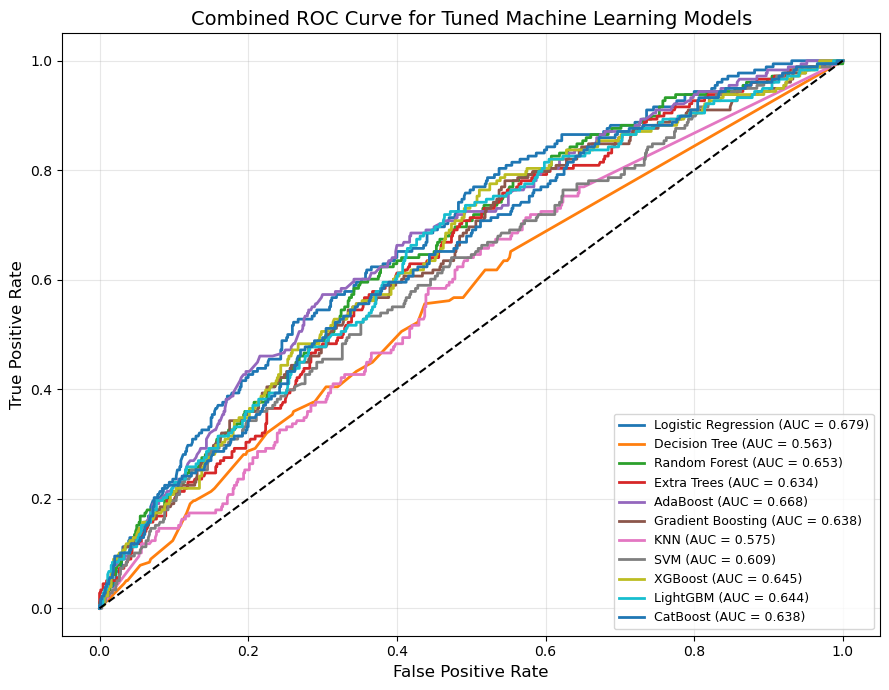

In [18]:
# ==========================================================
# Step-18 : Combined ROC Curve (All Tuned Models)
# ==========================================================

plt.figure(figsize=(9,7))

roc_auc_dict = {}

for name, model in best_models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    roc_auc_dict[name] = auc_score

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    lw=1.5
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Combined ROC Curve for Tuned Machine Learning Models",
    fontsize=14
)

plt.legend(
    fontsize=9,
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

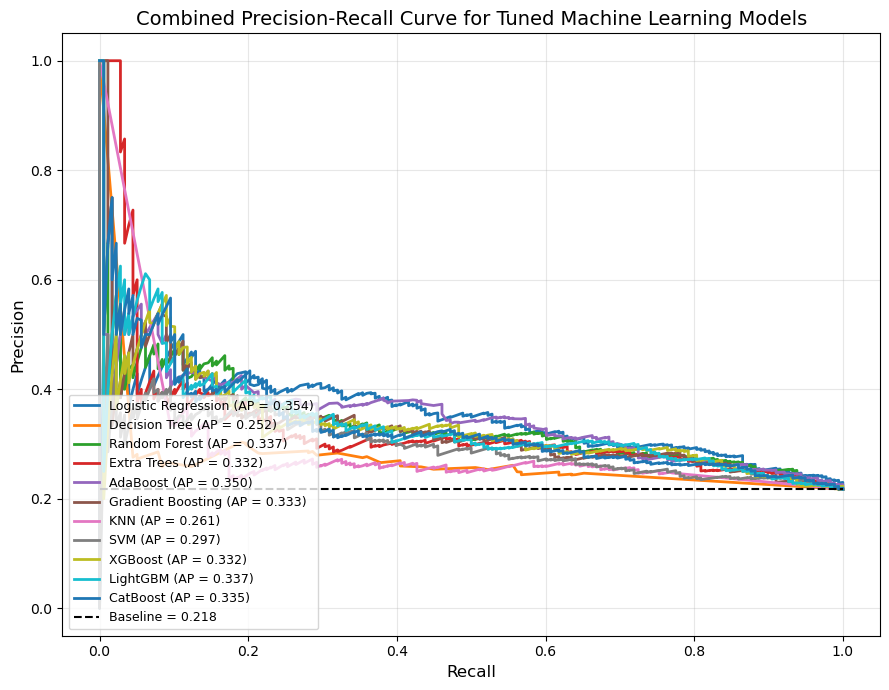

In [19]:
# ==========================================================
# Step-19 : Combined Precision-Recall Curve
# ==========================================================

plt.figure(figsize=(9,7))

ap_scores = {}

for name, model in best_models.items():

    y_prob = model.predict_proba(
        X_test
    )[:,1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    ap_scores[name] = ap

    plt.plot(
        recall,
        precision,
        lw=2,
        label=f"{name} (AP = {ap:.3f})"
    )

baseline = y_test.mean()

plt.hlines(
    baseline,
    0,
    1,
    linestyle="--",
    color="black",
    lw=1.5,
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Combined Precision-Recall Curve for Tuned Machine Learning Models",
    fontsize=14
)

plt.legend(
    fontsize=9,
    loc="lower left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [20]:
# ==========================================================
# Step-20 : Best Model Selection
# (Multi-Metric Ranking)
# ==========================================================

print("=" * 70)
print("MULTI-METRIC MODEL RANKING")
print("=" * 70)

ranking_df = tuned_df.copy()

# ----------------------------------------------------------
# Rank each metric
# ----------------------------------------------------------

higher_better = [

    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "Kappa",
    "MCC",
    "AUC"

]

for metric in higher_better:

    ranking_df[f"{metric}_Rank"] = (

        ranking_df[metric]

        .rank(

            ascending=False,

            method="min"

        )

    )

# Lower is better

ranking_df["LogLoss_Rank"] = (

    ranking_df["LogLoss"]

    .rank(

        ascending=True,

        method="min"

    )

)

# ----------------------------------------------------------
# Average Rank
# ----------------------------------------------------------

rank_columns = [

    c for c in ranking_df.columns

    if c.endswith("_Rank")

]

ranking_df["Average_Rank"] = (

    ranking_df[rank_columns]

    .mean(axis=1)

)

# ----------------------------------------------------------
# Final Ranking
# ----------------------------------------------------------

ranking_df = ranking_df.sort_values(

    "Average_Rank"

).reset_index(drop=True)

display(

    ranking_df[

        [

            "Model",

            "Accuracy",

            "Precision",

            "Recall",

            "Specificity",

            "F1",

            "Kappa",

            "MCC",

            "AUC",

            "LogLoss",

            "Average_Rank"

        ]

    ]

)

# ----------------------------------------------------------
# Best Model
# ----------------------------------------------------------

best_model_name = ranking_df.loc[0, "Model"]

final_model = best_models[best_model_name]

print("\n")

print("=" * 70)

print("BEST MODEL")

print("=" * 70)

print(f"Selected Model : {best_model_name}")

print(f"Average Rank   : {ranking_df.loc[0,'Average_Rank']:.2f}")

print("\nBest Parameters")

print(final_model.get_params())

MULTI-METRIC MODEL RANKING


,Model,Accuracy,Precision,Recall,Specificity,F1,Kappa,MCC,AUC,LogLoss,Average_Rank
0,AdaBoost,0.6809,0.3457,0.5225,0.7250,0.4161,0.2089,0.2174,0.6679,0.6459,4.111111
1,LightGBM,0.7531,0.3846,0.2247,0.9000,0.2837,0.1467,0.1545,0.6443,0.5416,4.222222
2,Random Forest,0.7445,0.3652,0.2360,0.8859,0.2867,0.1397,0.1447,0.6531,0.5304,4.555556
3,Logistic Regression,0.6406,0.3199,0.5787,0.6578,0.4120,0.1830,0.1997,0.6786,0.6232,4.888889
4,CatBoost,0.7641,0.4026,0.1742,0.9281,0.2431,0.1286,0.1445,0.6382,0.5307,4.888889
5,XGBoost,0.7494,0.3663,0.2079,0.9000,0.2652,0.1278,0.1353,0.6453,0.5391,5.555556
6,Gradient Boosting,0.7482,0.3654,0.2135,0.8969,0.2695,0.1298,0.1367,0.6376,0.5371,5.777778
7,Extra Trees,0.7494,0.3608,0.1966,0.9031,0.2545,0.1194,0.1273,0.6344,0.5337,6.666667
8,SVM,0.6430,0.2935,0.4551,0.6953,0.3568,0.1254,0.1312,0.6091,0.6769,7.444444
9,Decision Tree,0.6565,0.2771,0.3596,0.7391,0.3130,0.0890,0.0904,0.5629,4.0633,8.555556




BEST MODEL
Selected Model : AdaBoost
Average Rank   : 4.11

Best Parameters
{'algorithm': 'deprecated', 'estimator': None, 'learning_rate': 0.5, 'n_estimators': 300, 'random_state': None}


In [21]:
# ==========================================================
# Step-21 : Final Prediction using Best Tuned Model
# ==========================================================

print("=" * 70)
print("FINAL PREDICTION")
print("=" * 70)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:, 1]

print("Prediction completed successfully.")

print(f"\nBest Model : {best_model_name}")

print(f"Total Test Samples : {len(y_test)}")

print(f"Predicted Samples  : {len(y_pred)}")

FINAL PREDICTION
Prediction completed successfully.

Best Model : AdaBoost
Total Test Samples : 818
Predicted Samples  : 818


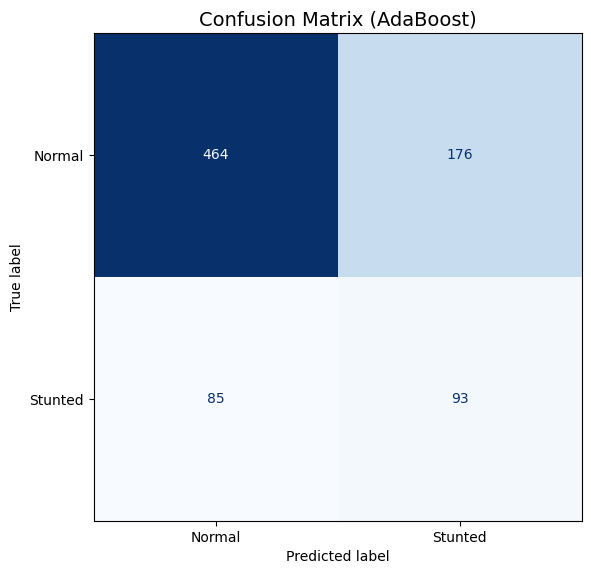

In [22]:
# ==========================================================
# Step-22 : Confusion Matrix
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Stunted"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title(
    f"Confusion Matrix ({best_model_name})",
    fontsize=14
)

plt.tight_layout()

plt.show()

In [23]:
# ==========================================================
# Step-23 : Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Normal",

            "Stunted"

        ]

    )

)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.85      0.72      0.78       640
     Stunted       0.35      0.52      0.42       178

    accuracy                           0.68       818
   macro avg       0.60      0.62      0.60       818
weighted avg       0.74      0.68      0.70       818



SHAP ANALYSIS
Model type: AdaBoostClassifier


PermutationExplainer explainer: 819it [25:48,  1.90s/it]                         


SHAP values calculated successfully.


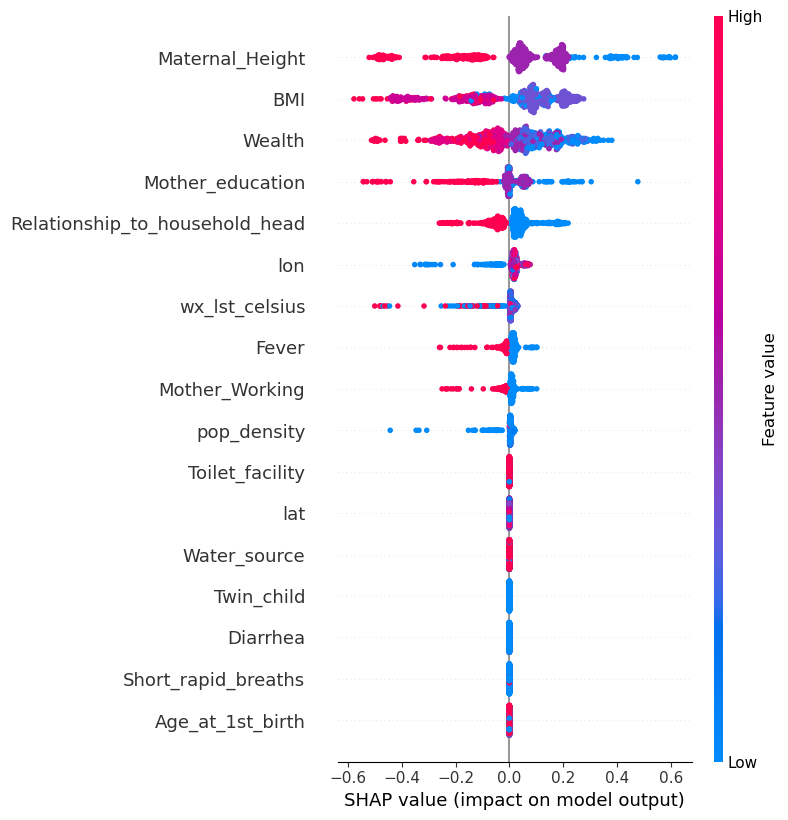

In [28]:
# ==========================================================
# Step-24 : SHAP Summary Plot
# ==========================================================
print("=" * 70)
print("SHAP ANALYSIS")
print("=" * 70)

from sklearn.pipeline import Pipeline

# ----------------------------------------------------------
# Unwrap Pipeline if final_model is one (SHAP needs the estimator itself)
# ----------------------------------------------------------
model_for_shap = final_model
X_test_transformed = X_test

if isinstance(final_model, Pipeline):
    # assumes last step is the estimator, everything before is preprocessing
    model_for_shap = final_model.steps[-1][1]
    preprocessing = Pipeline(final_model.steps[:-1])
    X_test_transformed = preprocessing.transform(X_test)
    print(f"Detected Pipeline. Using final step: {type(model_for_shap).__name__}")

print(f"Model type: {type(model_for_shap).__name__}")

# ----------------------------------------------------------
# SHAP Explainer (auto-select based on model type)
# ----------------------------------------------------------
tree_based = (
    "XGB" in type(model_for_shap).__name__
    or "LGBM" in type(model_for_shap).__name__
    or "CatBoost" in type(model_for_shap).__name__
    or "Forest" in type(model_for_shap).__name__
    or "GradientBoosting" in type(model_for_shap).__name__
    or "DecisionTree" in type(model_for_shap).__name__
    or "ExtraTrees" in type(model_for_shap).__name__
)

try:
    if tree_based:
        explainer = shap.TreeExplainer(model_for_shap)
        shap_values = explainer.shap_values(X_test_transformed)
    else:
        # Generic explainer works for linear, SVM, ensembles-of-mixed-type, etc.
        # Uses a background sample for speed
        background = shap.sample(X_test_transformed, min(100, len(X_test_transformed)))
        explainer = shap.Explainer(model_for_shap.predict, background)
        shap_values = explainer(X_test_transformed)
except Exception as e:
    print(f"TreeExplainer/auto path failed ({e}), falling back to generic Explainer...")
    background = shap.sample(X_test_transformed, min(100, len(X_test_transformed)))
    explainer = shap.Explainer(model_for_shap.predict, background)
    shap_values = explainer(X_test_transformed)

print("SHAP values calculated successfully.")

# ----------------------------------------------------------
# Summary Plot
# ----------------------------------------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=model_features,
    show=False
)
plt.tight_layout()
plt.show()

,Feature,Mean_SHAP
8,Maternal_Height,0.168279
7,BMI,0.152032
10,Wealth,0.125312
14,Mother_education,0.062107
12,Relationship_to_household_head,0.055489
16,lon,0.030272
5,wx_lst_celsius,0.023796
3,Fever,0.019300
0,Mother_Working,0.016357
9,pop_density,0.009850


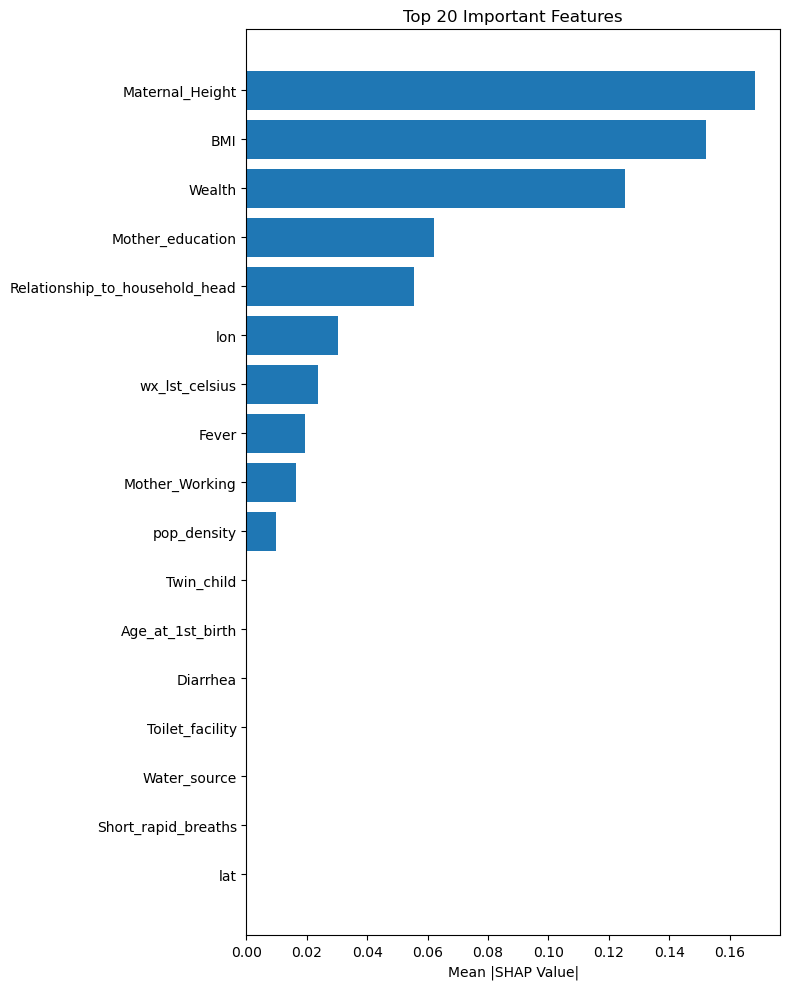

In [32]:
# ==========================================================
# Step-25 : SHAP Feature Importance
# ==========================================================

# Explanation object হলে .values বের করে নাও, নাহলে সরাসরি ব্যবহার করো
if hasattr(shap_values, "values"):
    shap_array = shap_values.values
else:
    shap_array = shap_values

# multi-class হলে (3D array) শুধু positive class (index 1) নাও
if isinstance(shap_array, list):
    shap_array = shap_array[1] if len(shap_array) > 1 else shap_array[0]
elif shap_array.ndim == 3:
    shap_array = shap_array[:, :, 1]

importance = np.abs(shap_array).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": model_features,
    "Mean_SHAP": importance
})

shap_importance = shap_importance.sort_values(
    "Mean_SHAP",
    ascending=False
)

display(shap_importance)

plt.figure(figsize=(8,10))
plt.barh(
    shap_importance["Feature"][:20][::-1],
    shap_importance["Mean_SHAP"][:20][::-1]
)
plt.xlabel("Mean |SHAP Value|")
plt.title("Top 20 Important Features")
plt.tight_layout()
plt.show()

In [34]:
# ==========================================================
# Step-26 : SHAP Dependence Plot
# ==========================================================

importance = np.abs(shap_values).mean(axis=0)

top_features = np.argsort(importance)[::-1][:5]

print("="*70)
print("TOP 5 SHAP FEATURES")
print("="*70)

for idx in top_features:

    feature = model_features[idx]

    print(feature)

    shap.dependence_plot(

        idx,

        shap_values,

        X_test,

        feature_names=model_features

    )

TypeError: bad operand type for abs(): 'Explanation'

In [ ]:
# ==========================================================
# Step-27 : SHAP Waterfall Plot
# ==========================================================

sample_index = 0

explanation = shap.Explanation(

    values=shap_values[sample_index],

    base_values=explainer.expected_value,

    data=X_test[sample_index],

    feature_names=model_features

)

shap.plots.waterfall(

    explanation,

    max_display=15

)

In [ ]:
# ==========================================================
# Step-28 : SHAP Force Plot
# ==========================================================

shap.initjs()

shap.force_plot(

    explainer.expected_value,

    shap_values[0],

    X_test[0],

    feature_names=model_features

)

In [ ]:
# ==========================================================
# Step-31 : Save Complete Spatial ML Workspace
# ==========================================================

import joblib
import os

print("=" * 70)
print("SAVING COMPLETE SPATIAL ML WORKSPACE")
print("=" * 70)

# ----------------------------------------------------------
# Create Folder
# ----------------------------------------------------------

save_path = "SpatialML_Saved"

os.makedirs(
    save_path,
    exist_ok=True
)

# ----------------------------------------------------------
# Best Tuned Model
# ----------------------------------------------------------

joblib.dump(
    final_model,
    os.path.join(save_path, "best_model.pkl")
)

# ----------------------------------------------------------
# All Tuned Models
# ----------------------------------------------------------

joblib.dump(
    best_models,
    os.path.join(save_path, "all_tuned_models.pkl")
)

# ----------------------------------------------------------
# Scaler
# ----------------------------------------------------------

joblib.dump(
    scaler,
    os.path.join(save_path, "scaler.pkl")
)

# ----------------------------------------------------------
# Feature Names
# ----------------------------------------------------------

joblib.dump(
    model_features,
    os.path.join(save_path, "model_features.pkl")
)

# ----------------------------------------------------------
# Training Data
# ----------------------------------------------------------

joblib.dump(
    X_train,
    os.path.join(save_path, "X_train.pkl")
)

joblib.dump(
    y_train,
    os.path.join(save_path, "y_train.pkl")
)

# ----------------------------------------------------------
# Testing Data
# ----------------------------------------------------------

joblib.dump(
    X_test,
    os.path.join(save_path, "X_test.pkl")
)

joblib.dump(
    y_test,
    os.path.join(save_path, "y_test.pkl")
)

# ----------------------------------------------------------
# Coordinates
# ----------------------------------------------------------

joblib.dump(
    coords_train,
    os.path.join(save_path, "coords_train.pkl")
)

joblib.dump(
    coords_test,
    os.path.join(save_path, "coords_test.pkl")
)

# ----------------------------------------------------------
# Groups
# ----------------------------------------------------------

joblib.dump(
    groups_train,
    os.path.join(save_path, "groups_train.pkl")
)

joblib.dump(
    groups_test,
    os.path.join(save_path, "groups_test.pkl")
)

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

joblib.dump(
    y_pred,
    os.path.join(save_path, "y_pred.pkl")
)

joblib.dump(
    y_prob,
    os.path.join(save_path, "y_prob.pkl")
)

# ----------------------------------------------------------
# Results Tables
# ----------------------------------------------------------

joblib.dump(
    default_df,
    os.path.join(save_path, "default_results.pkl")
)

joblib.dump(
    tuned_df,
    os.path.join(save_path, "tuned_results.pkl")
)

joblib.dump(
    ranking_df,
    os.path.join(save_path, "ranking_results.pkl")
)

# ----------------------------------------------------------
# Final Dataset
# ----------------------------------------------------------

joblib.dump(
    df,
    os.path.join(save_path, "final_dataset.pkl")
)

# ----------------------------------------------------------
# Feature Matrix
# ----------------------------------------------------------

joblib.dump(
    X,
    os.path.join(save_path, "feature_matrix.pkl")
)

joblib.dump(
    y,
    os.path.join(save_path, "target_vector.pkl")
)

# ----------------------------------------------------------
# Spatial Information
# ----------------------------------------------------------

joblib.dump(
    groups,
    os.path.join(save_path, "all_groups.pkl")
)

joblib.dump(
    coordinates,
    os.path.join(save_path, "all_coordinates.pkl")
)

# ----------------------------------------------------------
# Selected Variables
# ----------------------------------------------------------

joblib.dump(
    selected_vars,
    os.path.join(save_path, "selected_variables.pkl")
)

joblib.dump(
    wx_vars,
    os.path.join(save_path, "wx_variables.pkl")
)

joblib.dump(
    env_vars,
    os.path.join(save_path, "environment_variables.pkl")
)

joblib.dump(
    socio_vars,
    os.path.join(save_path, "socioeconomic_variables.pkl")
)

# ----------------------------------------------------------
# Save Confirmation
# ----------------------------------------------------------

print("\nAll Spatial ML objects saved successfully.")

print(f"\nSaved Folder : {save_path}")

print("\nSaved Files:")

for file in sorted(os.listdir(save_path)):
    print("✓", file)

In [ ]:
pip install geoshapley

In [ ]:
import geoshapley

print(dir(geoshapley))

In [ ]:
from geoshapley import GeoShapleyTreeExplainer

help(GeoShapleyTreeExplainer)

In [ ]:
from geoshapley import GeoShapleyExplainer

help(GeoShapleyExplainer)

In [ ]:
import joblib
import os

save_path = "SpatialML_Saved"

final_model = joblib.load(os.path.join(save_path, "best_model.pkl"))
best_models = joblib.load(os.path.join(save_path, "all_tuned_models.pkl"))
scaler = joblib.load(os.path.join(save_path, "scaler.pkl"))

X_train = joblib.load(os.path.join(save_path, "X_train.pkl"))
X_test = joblib.load(os.path.join(save_path, "X_test.pkl"))
y_train = joblib.load(os.path.join(save_path, "y_train.pkl"))
y_test = joblib.load(os.path.join(save_path, "y_test.pkl"))

coords_train = joblib.load(os.path.join(save_path, "coords_train.pkl"))
coords_test = joblib.load(os.path.join(save_path, "coords_test.pkl"))

model_features = joblib.load(os.path.join(save_path, "model_features.pkl"))

y_pred = joblib.load(os.path.join(save_path, "y_pred.pkl"))
y_prob = joblib.load(os.path.join(save_path, "y_prob.pkl"))

default_df = joblib.load(os.path.join(save_path, "default_results.pkl"))
tuned_df = joblib.load(os.path.join(save_path, "tuned_results.pkl"))
ranking_df = joblib.load(os.path.join(save_path, "ranking_results.pkl"))

df = joblib.load(os.path.join(save_path, "final_dataset.pkl"))
X = joblib.load(os.path.join(save_path, "feature_matrix.pkl"))
y = joblib.load(os.path.join(save_path, "target_vector.pkl"))

groups = joblib.load(os.path.join(save_path, "all_groups.pkl"))
coordinates = joblib.load(os.path.join(save_path, "all_coordinates.pkl"))

selected_vars = joblib.load(os.path.join(save_path, "selected_variables.pkl"))
wx_vars = joblib.load(os.path.join(save_path, "wx_variables.pkl"))
env_vars = joblib.load(os.path.join(save_path, "environment_variables.pkl"))
socio_vars = joblib.load(os.path.join(save_path, "socioeconomic_variables.pkl"))

print("Workspace restored successfully.")

In [ ]:
# ==========================================================
# Step-32 (Fixed) : Keep REAL (unscaled) lat/lon alongside
#                   the scaled features used for the model
# ==========================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Real, unscaled coordinates (from Step-9's `coordinates`,
# split in Step-10 into coords_train / coords_test)
# coords_train/coords_test columns are ["lon", "lat"] — unscaled
# ----------------------------------------------------------

real_train_lon = coords_train[:, 0]
real_train_lat = coords_train[:, 1]
real_test_lon  = coords_test[:, 0]
real_test_lat  = coords_test[:, 1]

# ----------------------------------------------------------
# Build the scaled feature frames (used for the MODEL)
# ----------------------------------------------------------

X_train_full = pd.DataFrame(X_train, columns=model_features)
X_test_full  = pd.DataFrame(X_test,  columns=model_features)

# Attach real coordinates as separate columns (for mapping only)
X_train_full["real_lat"] = real_train_lat
X_train_full["real_lon"] = real_train_lon
X_test_full["real_lat"]  = real_test_lat
X_test_full["real_lon"]  = real_test_lon

# ----------------------------------------------------------
# Reduced feature set for GeoShapley (still uses SCALED lat/lon
# because that's what the model was trained on)
# ----------------------------------------------------------

top_features = (
    shap_importance
    .sort_values("Mean_SHAP", ascending=False)
    .head(N_TOP_FEATURES)["Feature"]
    .tolist()
)

coord_cols = ["lat", "lon"]
geo_feature_list = [f for f in top_features if f not in coord_cols] + coord_cols

X_train_geo = X_train_full[geo_feature_list].reset_index(drop=True)
X_test_geo  = X_test_full[geo_feature_list].reset_index(drop=True)

# Keep the REAL coords aligned to the same row order (for plotting later)
X_train_real_coords = X_train_full[["real_lat", "real_lon"]].reset_index(drop=True)
X_test_real_coords  = X_test_full[["real_lat", "real_lon"]].reset_index(drop=True)

background = X_train_geo.sample(n=min(30, len(X_train_geo)), random_state=42)
background_idx = background.index          # <-- remember before reset
background = background.reset_index(drop=True)

In [ ]:
# ==========================================================
# Step-33 (Revised) : Build GeoShapley Explainer
# ==========================================================

from geoshapley import GeoShapleyExplainer

print("=" * 70)
print("BUILDING GEOSHAPLEY EXPLAINER (REDUCED FEATURES)")
print("=" * 70)

fixed_features = [f for f in model_features if f not in geo_feature_list]
fixed_values = X_train_full[fixed_features].mean()

def predict_probability(data):

    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data, columns=geo_feature_list)

    full_data = pd.DataFrame(
        np.tile(fixed_values.values, (len(data), 1)),
        columns=fixed_features
    )
    full_data[geo_feature_list] = data.values
    full_data = full_data[model_features]

    return final_model.predict_proba(full_data)[:, 1]

geo_explainer = GeoShapleyExplainer(
    predict_f=predict_probability,
    background=background,
    g=2,
    exact=False
)

print("GeoShapley Explainer created successfully with", len(geo_feature_list), "features.")

In [ ]:
# ==========================================================
# Step-34 (Fixed) : Compute GeoShapley Values
# ==========================================================
print("=" * 70)
print("COMPUTING GEOSHAPLEY VALUES")
print("=" * 70)

sample_positions = X_test_geo.sample(
    n=min(30, len(X_test_geo)),
    random_state=42
).index                                   # <-- আসল index সংরক্ষণ

X_geo_sample = X_test_geo.loc[sample_positions].reset_index(drop=True)
real_coords_sample = X_test_real_coords.loc[sample_positions].reset_index(drop=True)

print("Sample Size :", len(X_geo_sample))
print("Feature count going into GeoShapley:", X_geo_sample.shape[1])

geo_results = geo_explainer.explain(
    X_geo_sample,
    n_jobs=1
)
print("\nGeoShapley completed successfully.")

In [ ]:
# ==========================================================
# Step-35 : Inspect GeoShapley Results
# ==========================================================

print("=" * 70)
print("GEOSHAPLEY RESULTS")
print("=" * 70)

print(type(geo_results))

print("\nAvailable Attributes:\n")

print(dir(geo_results))

In [ ]:
# ==========================================================
# Step-36 : GeoShapley Summary Plot
# ==========================================================

print("=" * 70)
print("GEOSHAPLEY SUMMARY PLOT")
print("=" * 70)

geo_results.summary_plot()

In [ ]:
# ==========================================================
# Step-37 : GeoShapley Ranked Contribution Bar Plot
# ==========================================================

print("=" * 70)
print("GEOSHAPLEY CONTRIBUTION BAR PLOT")
print("=" * 70)

geo_results.contribution_bar_plot()

In [ ]:
# ==========================================================
# Step-38 : Partial Dependence Plots (Primary / Non-spatial Effects)
# ==========================================================

print("=" * 70)
print("PARTIAL DEPENDENCE PLOTS (NON-SPATIAL)")
print("=" * 70)

geo_results.partial_dependence_plots()

In [ ]:
# ==========================================================
# Step-39 : Spatially Varying Coefficients (SVC) — Top-N Features
# ==========================================================
print("=" * 70)
print("SPATIALLY VARYING COEFFICIENTS (TOP FEATURES)")
print("=" * 70)

svc_features = [f for f in geo_feature_list if f not in coord_cols]
feature_names_geo = list(X_geo_sample.columns[:-len(coord_cols)])

print("Computing SVC for features:")
print(svc_features)

svc_dict = {}
for feat in svc_features:
    idx = feature_names_geo.index(feat)
    svc_values = geo_results.get_svc([idx], coef_type="gwr")
    svc_dict[feat] = svc_values.ravel()

# REAL lat/lon ব্যবহার করে cluster_geo বানান
cluster_geo = pd.DataFrame({
    "lat": real_coords_sample["real_lat"].values,
    "lon": real_coords_sample["real_lon"].values,
})
for feat in svc_features:
    cluster_geo[feat] = svc_dict[feat]

print("\nCluster-level SVC table:")
print(cluster_geo.head())

# যাচাই — lat আসলে ২০-২৭ আর lon ৮৮-৯৩ এর মধ্যে থাকা উচিত
print(cluster_geo[["lat","lon"]].describe())

In [ ]:
# ==========================================================
# Step-40 : Cluster-wise GeoSHAP Map — Loop Over Top-N Features
# ==========================================================
import geopandas as gpd
import matplotlib.pyplot as plt

print("=" * 70)
print("CLUSTER-WISE GEOSHAP MAPS (TOP FEATURES)")
print("=" * 70)

divisions = gpd.read_file(r"F:\Thesis\GPS DATA\Division\gadm41_BGD_shp\gadm41_BGD_1.shp")
name_col = "NAME_1"

for best_feature in svc_features:

    vals = cluster_geo[best_feature].fillna(0)
    abs_max = max(abs(vals.min()), abs(vals.max()))
    cluster_geo_sorted = cluster_geo.sort_values(by=best_feature)

    fig, ax = plt.subplots(figsize=(10, 10))
    divisions.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=1.2)

    sc = ax.scatter(
        cluster_geo_sorted["lon"],
        cluster_geo_sorted["lat"],
        c=cluster_geo_sorted[best_feature],
        cmap="coolwarm",
        s=45,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.95,
        vmin=-abs_max,
        vmax=abs_max
    )

    cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cb.set_label(f"GeoSHAP ({best_feature})", fontsize=12)

    for _, row in divisions.iterrows():
        ax.text(
            row.geometry.centroid.x,
            row.geometry.centroid.y,
            row[name_col],
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(f"Cluster-wise GeoSHAP Map ({best_feature})", fontsize=15, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(f"geoshap_map_{best_feature}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# ==========================================================
# Step-41 : Reusable GeoShapley + SVC + Map Pipeline
#           (Encapsulates Step-33 to Step-40 logic)
# ==========================================================
import geopandas as gpd
import matplotlib.pyplot as plt

def run_geoshapley_pipeline(selected_vars, tag):
    """
    selected_vars : non-coordinate feature list (lat/lon যোগ হবে ভেতরেই)
    tag           : output ফাইল নাম আলাদা রাখার জন্য (e.g. 'bilisa', 'pvalue')
    """
    print("=" * 70)
    print(f"RUNNING PIPELINE FOR: {tag.upper()}  |  Features: {selected_vars}")
    print("=" * 70)

    coord_cols = ["lat", "lon"]
    geo_feature_list = [f for f in selected_vars if f not in coord_cols] + coord_cols

    X_train_geo = X_train_full[geo_feature_list].reset_index(drop=True)
    X_test_geo  = X_test_full[geo_feature_list].reset_index(drop=True)

    background = X_train_geo.sample(n=min(30, len(X_train_geo)), random_state=42).reset_index(drop=True)

    # ---- Explainer ----
    fixed_features = [f for f in model_features if f not in geo_feature_list]
    fixed_values = X_train_full[fixed_features].mean()

    def predict_probability(data):
        if isinstance(data, np.ndarray):
            data = pd.DataFrame(data, columns=geo_feature_list)
        full_data = pd.DataFrame(
            np.tile(fixed_values.values, (len(data), 1)),
            columns=fixed_features
        )
        full_data[geo_feature_list] = data.values
        full_data = full_data[model_features]
        return final_model.predict_proba(full_data)[:, 1]

    geo_explainer = GeoShapleyExplainer(
        predict_f=predict_probability,
        background=background,
        g=2,
        exact=False
    )

    # ---- Sample + Explain ----
    sample_positions = X_test_geo.sample(n=min(30, len(X_test_geo)), random_state=42).index
    X_geo_sample = X_test_geo.loc[sample_positions].reset_index(drop=True)
    real_coords_sample = X_test_real_coords.loc[sample_positions].reset_index(drop=True)

    geo_results = geo_explainer.explain(X_geo_sample, n_jobs=1)

    # ---- SVC ----
    svc_features = [f for f in geo_feature_list if f not in coord_cols]
    feature_names_geo = list(X_geo_sample.columns[:-len(coord_cols)])

    svc_dict = {}
    for feat in svc_features:
        idx = feature_names_geo.index(feat)
        svc_values = geo_results.get_svc([idx], coef_type="gwr")
        svc_dict[feat] = svc_values.ravel()

    cluster_geo = pd.DataFrame({
        "lat": real_coords_sample["real_lat"].values,
        "lon": real_coords_sample["real_lon"].values,
    })
    for feat in svc_features:
        cluster_geo[feat] = svc_dict[feat]

    # ---- Maps ----
    for best_feature in svc_features:
        vals = cluster_geo[best_feature].fillna(0)
        abs_max = max(abs(vals.min()), abs(vals.max()))
        cluster_geo_sorted = cluster_geo.sort_values(by=best_feature)

        fig, ax = plt.subplots(figsize=(10, 10))
        divisions.plot(ax=ax, color="#f5f5f5", edgecolor="black", linewidth=1.2)
        sc = ax.scatter(
            cluster_geo_sorted["lon"], cluster_geo_sorted["lat"],
            c=cluster_geo_sorted[best_feature], cmap="coolwarm",
            s=45, edgecolor="black", linewidth=0.4, alpha=0.95,
            vmin=-abs_max, vmax=abs_max
        )
        cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
        cb.set_label(f"GeoSHAP ({best_feature})", fontsize=12)
        for _, row in divisions.iterrows():
            ax.text(row.geometry.centroid.x, row.geometry.centroid.y,
                    row["NAME_1"], ha="center", fontsize=10, fontweight="bold")
        ax.set_title(f"[{tag}] Cluster-wise GeoSHAP Map ({best_feature})", fontsize=14, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        plt.tight_layout()
        plt.savefig(f"geoshap_{tag}_{best_feature}.png", dpi=300, bbox_inches="tight")
        plt.show()

    return geo_results, cluster_geo, svc_features

In [ ]:
# ==========================================================
# Step-43 : Feature Selection via Statistical Significance (p < 0.05)
# ==========================================================
import statsmodels.api as sm

X_sm = X_train_full[model_features].astype(float)
X_sm = sm.add_constant(X_sm)

logit_model = sm.Logit(y_train, X_sm)
logit_result = logit_model.fit(disp=0)

print(logit_result.summary())

pvals = logit_result.pvalues.drop("const")
significant_vars = pvals[pvals < 0.05].index.tolist()

print("\nSignificant Variables (p < 0.05):")
print(significant_vars)

geo_results_pval, cluster_geo_pval, svc_features_pval = run_geoshapley_pipeline(
    selected_vars=significant_vars,
    tag="pvalue"
)

In [ ]:
# ==========================================================
# Step-44 : Feature Selection via RFE (Wrapper-based)
# ==========================================================
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe_estimator = RandomForestClassifier(n_estimators=200, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=N_TOP_FEATURES)
rfe.fit(X_train_full[model_features], y_train)

rfe_selected_vars = [f for f, keep in zip(model_features, rfe.support_) if keep]

print("RFE-selected Variables:")
print(rfe_selected_vars)

geo_results_rfe, cluster_geo_rfe, svc_features_rfe = run_geoshapley_pipeline(
    selected_vars=rfe_selected_vars,
    tag="rfe"
)

In [ ]:
# ==========================================================
# Step-44b (Alternative) : Permutation Importance
# ==========================================================
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    final_model,
    X_test_full[model_features],
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_importance_df = pd.DataFrame({
    "Feature": model_features,
    "Importance": perm_result.importances_mean
}).sort_values("Importance", ascending=False)

perm_selected_vars = perm_importance_df.head(N_TOP_FEATURES)["Feature"].tolist()

print("Permutation Importance-selected Variables:")
print(perm_selected_vars)

geo_results_perm, cluster_geo_perm, svc_features_perm = run_geoshapley_pipeline(
    selected_vars=perm_selected_vars,
    tag="permimp"
)